
# Tutorial 2 - Hall effect simulation: carrier type, carrier density, and mobility

**Course:** Power Electronics Devices and Components  
**Lecture linkage:** Hall effect, Hall voltage, carrier type, carrier concentration, mobility, conductivity

## Why this tutorial matters
The Hall effect is one of the most useful bridges between semiconductor physics and experiment. With one measurement setup, students can learn how to:
- distinguish **n-type** and **p-type** material,
- estimate the **majority-carrier concentration**, and
- infer **mobility** when conductivity is known.

## Governing equations used in this notebook
For a single dominant carrier type,

\[
R_H = \frac{1}{q p} \quad \text{(p-type)}, \qquad R_H = -\frac{1}{q n} \quad \text{(n-type)}
\]

\[
V_H = R_H \frac{I B}{t}
\]

\[
\mu = \sigma |R_H|
\]

where:
- \(R_H\) = Hall coefficient,
- \(V_H\) = Hall voltage,
- \(I\) = current through the sample,
- \(B\) = magnetic field,
- \(t\) = sample thickness,
- \(\sigma\) = conductivity,
- \(\mu\) = mobility.

## Fixed values for this tutorial
Use the following values unless a question explicitly asks you to vary them:

- Elementary charge: \(q = 1.602\times10^{-19}\,\mathrm{C}\)
- Sample current: \(I = 5\,\mathrm{mA}\)
- Sample thickness: \(t = 500\,\mu\mathrm{m}\)
- Magnetic-field sweep for Part A: \(B = -1\) to \(+1\,\mathrm{T}\)
- Magnetic-field sweep for Part B: \(B = -0.8\) to \(+0.8\,\mathrm{T}\), 21 points
- Noise standard deviation for synthetic data: \(20\,\mu\mathrm{V}\)

## Carrier concentrations to be used
Instead of simulating only one n-type and one p-type sample, use a **set of doping levels** so that you can immediately see the effect of changing carrier density.

### n-type samples
\[
 n = \left[10^{15},\;5\times10^{15},\;10^{16},\;10^{17}\right]\;\mathrm{cm^{-3}}
\]

### p-type samples
\[
 p = \left[10^{15},\;5\times10^{15},\;10^{16},\;10^{17}\right]\;\mathrm{cm^{-3}}
\]

## Student tasks

### Part A - Hall voltage vs magnetic field
Using the fixed values above and the four carrier concentrations for each material type:
1. Simulate \(V_H(B)\) for **all four n-type samples**.
2. Simulate \(V_H(B)\) for **all four p-type samples**.
3. Plot the n-type family on one graph and the p-type family on another graph.
4. Then make one combined plot containing **one n-type sample and one p-type sample**, both at \(5\times10^{15}\,\mathrm{cm^{-3}}\).
5. From the plots, explain:
   - why the sign of \(V_H\) changes between n-type and p-type,
   - why the slope \(dV_H/dB\) becomes smaller when the doping level increases.

### Part B - Extract carrier density from synthetic Hall data
Use the following measurement case:
- sample type: **n-type**
- true carrier concentration: \(n = 5\times10^{15}\,\mathrm{cm^{-3}}\)
- current: \(I = 5\,\mathrm{mA}\)
- thickness: \(t = 500\,\mu\mathrm{m}\)
- magnetic field: 21 points from \(-0.8\) to \(+0.8\,\mathrm{T}\)
- Gaussian noise standard deviation: \(20\,\mu\mathrm{V}\)

Tasks:
1. Generate synthetic noisy Hall-voltage data.
2. Fit a straight line to \(V_H\) versus \(B\).
3. From the fitted slope, estimate the Hall coefficient \(R_H\).
4. From \(R_H\), estimate the carrier concentration.
5. Compare the estimated value with the true value and compute the percentage error.

### Part C - Estimate mobility from Hall coefficient and conductivity
Use the Hall coefficient obtained in Part B and assume the measured conductivity of the same sample is:

\[
\sigma = 100\;\mathrm{S/m}
\]

Tasks:
1. Compute the carrier mobility using \(\mu = \sigma |R_H|\).
2. Convert the result from \(\mathrm{m^2/(V\cdot s)}\) to \(\mathrm{cm^2/(V\cdot s)}\).
3. Compare your result with the typical room-temperature electron mobility in silicon.
4. State clearly why the single-carrier Hall formula becomes less accurate in materials where both carrier types contribute significantly.

## What students should learn from this notebook
By the end of this tutorial, students should be able to explain that:
- Hall-voltage **sign** identifies majority-carrier type,
- Hall-voltage **slope** is inversely related to carrier concentration,
- lower-doped samples give a **larger Hall voltage** and are therefore easier to detect,
- Hall-effect data can be used to estimate both **carrier density** and **mobility**.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Constants and fixed measurement values for the tutorial
# ---------------------------------------------------------------------
q = 1.602176634e-19   # elementary charge, C
I = 5e-3              # current, A
t = 500e-6            # sample thickness, m

# Carrier concentrations in cm^-3 (student task values)
n_values_cm3 = np.array([1e15, 5e15, 1e16, 1e17])
p_values_cm3 = np.array([1e15, 5e15, 1e16, 1e17])

# Convert to m^-3 for SI calculations
n_values_m3 = n_values_cm3 * 1e6
p_values_m3 = p_values_cm3 * 1e6

# Magnetic-field sweep for Part A
B = np.linspace(-1.0, 1.0, 300)  # tesla

# Hall coefficients for single-carrier approximation
RH_n = -1 / (q * n_values_m3)     # n-type
RH_p =  1 / (q * p_values_m3)     # p-type

print('Fixed values used in this tutorial:')
print(f'  Current I = {I*1e3:.1f} mA')
print(f'  Thickness t = {t*1e6:.0f} um')
print(f'  n-type carrier concentrations (cm^-3) = {n_values_cm3}')
print(f'  p-type carrier concentrations (cm^-3) = {p_values_cm3}')


Fixed values used in this tutorial:
  Current I = 5.0 mA
  Thickness t = 500 um
  n-type carrier concentrations (cm^-3) = [1.e+15 5.e+15 1.e+16 1.e+17]
  p-type carrier concentrations (cm^-3) = [1.e+15 5.e+15 1.e+16 1.e+17]


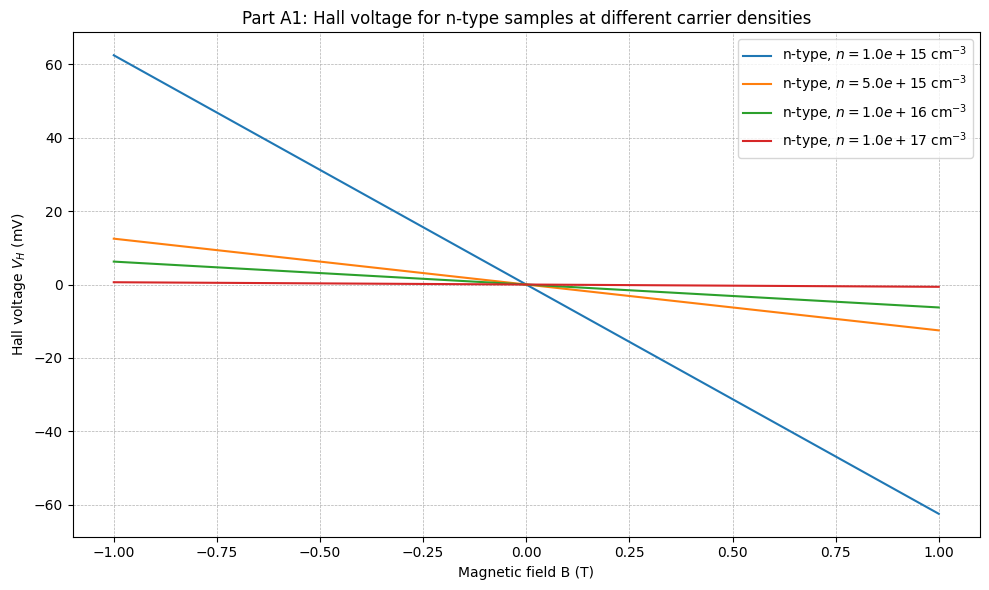

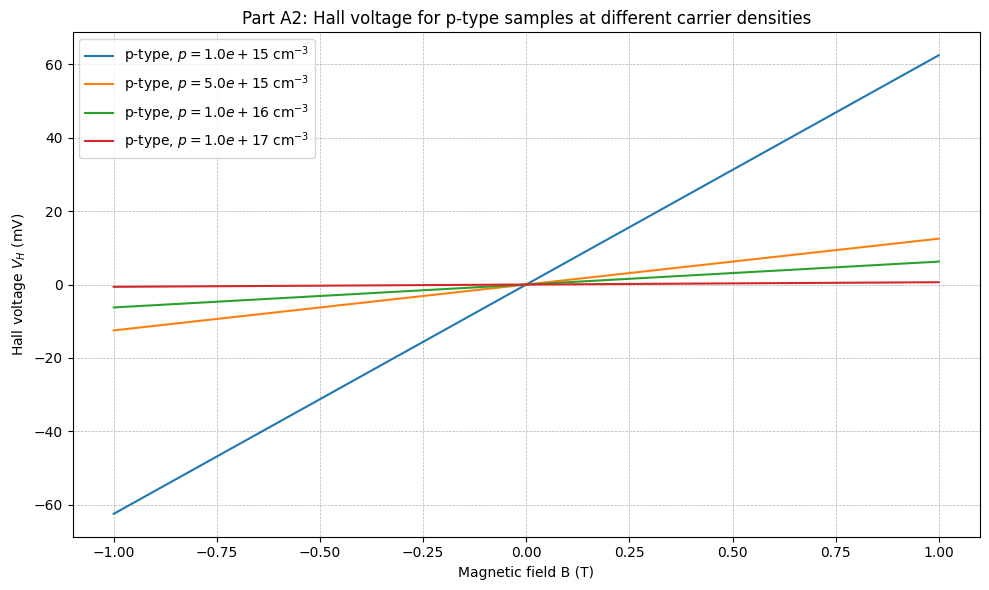

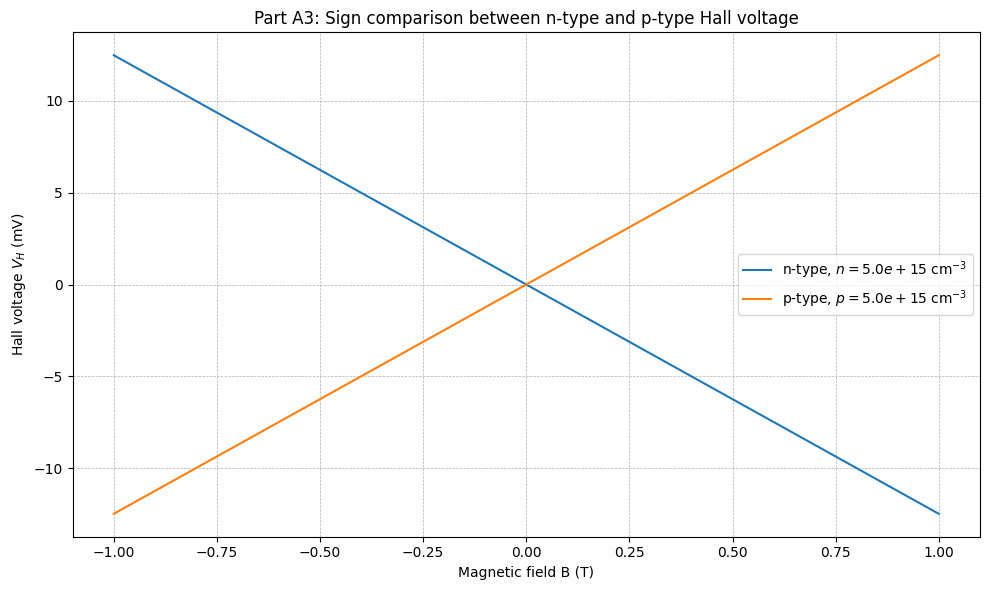

In [2]:

# ---------------------------------------------------------------------
# Part A - Hall voltage versus magnetic field for multiple doping levels
# ---------------------------------------------------------------------
plt.figure(figsize=(10, 6))
for n_cm3, RH in zip(n_values_cm3, RH_n):
    VH = RH * I * B / t
    plt.plot(B, VH * 1e3, label=fr'n-type, $n={n_cm3:.1e}\;\mathrm{{cm^{{-3}}}}$')

plt.xlabel('Magnetic field B (T)')
plt.ylabel('Hall voltage $V_H$ (mV)')
plt.title('Part A1: Hall voltage for n-type samples at different carrier densities')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
for p_cm3, RH in zip(p_values_cm3, RH_p):
    VH = RH * I * B / t
    plt.plot(B, VH * 1e3, label=fr'p-type, $p={p_cm3:.1e}\;\mathrm{{cm^{{-3}}}}$')

plt.xlabel('Magnetic field B (T)')
plt.ylabel('Hall voltage $V_H$ (mV)')
plt.title('Part A2: Hall voltage for p-type samples at different carrier densities')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Combined comparison at the same magnitude of carrier concentration
n_ref_cm3 = 5e15
p_ref_cm3 = 5e15
n_ref_m3 = n_ref_cm3 * 1e6
p_ref_m3 = p_ref_cm3 * 1e6
RH_n_ref = -1 / (q * n_ref_m3)
RH_p_ref =  1 / (q * p_ref_m3)
VH_n_ref = RH_n_ref * I * B / t
VH_p_ref = RH_p_ref * I * B / t

plt.figure(figsize=(10, 6))
plt.plot(B, VH_n_ref * 1e3, label=fr'n-type, $n={n_ref_cm3:.1e}\;\mathrm{{cm^{{-3}}}}$')
plt.plot(B, VH_p_ref * 1e3, label=fr'p-type, $p={p_ref_cm3:.1e}\;\mathrm{{cm^{{-3}}}}$')
plt.xlabel('Magnetic field B (T)')
plt.ylabel('Hall voltage $V_H$ (mV)')
plt.title('Part A3: Sign comparison between n-type and p-type Hall voltage')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


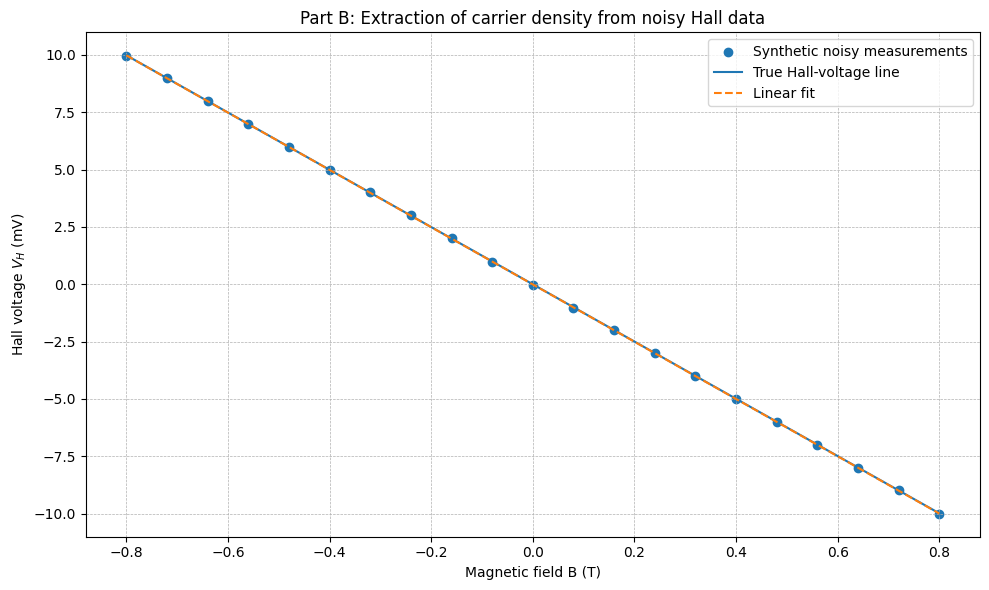

--- Part B results ---
True carrier concentration      = 5.000e+15 cm^-3
Estimated Hall coefficient RH   = -1.249e-03 m^3/C
Estimated carrier concentration = 4.998e+15 cm^-3
Percentage error               = 0.03 %


In [3]:

# ---------------------------------------------------------------------
# Part B - Synthetic noisy Hall data and extraction of carrier density
# ---------------------------------------------------------------------
rng = np.random.default_rng(10)

# Given task values
n_true_cm3 = 5e15
n_true_m3 = n_true_cm3 * 1e6
RH_true = -1 / (q * n_true_m3)
B_exp = np.linspace(-0.8, 0.8, 21)
noise_sigma = 20e-6  # 20 microvolts

VH_true = RH_true * I * B_exp / t
VH_meas = VH_true + rng.normal(0.0, noise_sigma, size=B_exp.shape)

# Linear fit: VH = m*B + c
m_fit, c_fit = np.polyfit(B_exp, VH_meas, 1)
RH_est = m_fit * t / I
n_est_m3 = -1 / (q * RH_est)
n_est_cm3 = n_est_m3 / 1e6
percent_error = abs((n_est_cm3 - n_true_cm3) / n_true_cm3) * 100

plt.figure(figsize=(10, 6))
plt.scatter(B_exp, VH_meas * 1e3, label='Synthetic noisy measurements')
plt.plot(B_exp, VH_true * 1e3, label='True Hall-voltage line')
plt.plot(B_exp, (m_fit * B_exp + c_fit) * 1e3, '--', label='Linear fit')
plt.xlabel('Magnetic field B (T)')
plt.ylabel('Hall voltage $V_H$ (mV)')
plt.title('Part B: Extraction of carrier density from noisy Hall data')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

print('--- Part B results ---')
print(f'True carrier concentration      = {n_true_cm3:.3e} cm^-3')
print(f'Estimated Hall coefficient RH   = {RH_est:.3e} m^3/C')
print(f'Estimated carrier concentration = {n_est_cm3:.3e} cm^-3')
print(f'Percentage error               = {percent_error:.2f} %')


In [4]:

# ---------------------------------------------------------------------
# Part C - Mobility estimation from Hall coefficient and conductivity
# ---------------------------------------------------------------------
sigma_measured = 100.0  # S/m, given task value
mu_m2_per_Vs = sigma_measured * abs(RH_est)
mu_cm2_per_Vs = mu_m2_per_Vs * 1e4

print('--- Part C results ---')
print(f'Assumed measured conductivity sigma = {sigma_measured:.1f} S/m')
print(f'Estimated mobility mu               = {mu_m2_per_Vs:.4f} m^2/(V·s)')
print(f'Estimated mobility mu               = {mu_cm2_per_Vs:.1f} cm^2/(V·s)')
print('Typical room-temperature electron mobility in Si is on the order of 1350 cm^2/(V·s).')


--- Part C results ---
Assumed measured conductivity sigma = 100.0 S/m
Estimated mobility mu               = 0.1249 m^2/(V·s)
Estimated mobility mu               = 1248.7 cm^2/(V·s)
Typical room-temperature electron mobility in Si is on the order of 1350 cm^2/(V·s).



## Reflection and discussion questions
1. Which samples produced the largest Hall voltage magnitude: the lightly doped or heavily doped ones? Why?
2. Why does the Hall-voltage slope change sign between n-type and p-type samples?
3. Why is the Hall method often more sensitive for lower carrier concentrations?
4. In practical semiconductors, under what conditions would the single-carrier approximation become inaccurate?
5. How would reducing the sample thickness from \(500\,\mu\mathrm{m}\) to \(250\,\mu\mathrm{m}\) affect the Hall voltage?

## Suggested extensions for students
1. Repeat Part B for a **p-type** sample with \(p=10^{16}\,\mathrm{cm^{-3}}\).
2. Repeat the family plots for an additional high-doping point: \(10^{18}\,\mathrm{cm^{-3}}\).
3. Add random-noise levels of \(5\,\mu\mathrm{V}\), \(20\,\mu\mathrm{V}\), and \(100\,\mu\mathrm{V}\), then compare the extraction error in carrier density.
4. Use several conductivity values and study how the estimated mobility changes.